# 🔫 NYPD Shooting Incident — Fatal vs Non-Fatal Prediction
**Goal:** Predict whether a shooting incident is fatal (`STATISTICAL_MURDER_FLAG = True`) or non-fatal (`False`)

Pipeline:
1. Load & explore data (EDA)
2. Advanced Feature Engineering
3. Model Training (XGBoost + Random Forest + Logistic Regression)
4. Handle Overfitting / Underfitting
5. Confusion Matrix, ROC-AUC, Business Visualizations

## 📦 Step 1 — Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,f1_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📂 Step 2 — Load Dataset

In [ ]:
df = pd.read_csv('NYPD_Shooting_Incident_Data__Historic_.csv')
print('✅ Dataset loaded!')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns}')
df.head(3)


✅ Dataset loaded!
Shape: (27312, 21)
Columns: Index(['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO', 'LOC_OF_OCCUR_DESC',
       'PRECINCT', 'JURISDICTION_CODE', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC',
       'STATISTICAL_MURDER_FLAG', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
       'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD',
       'Latitude', 'Longitude', 'Lon_Lat'],
      dtype='object')


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.00000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.00000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.53125,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic Info ──
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['STATISTICAL_MURDER_FLAG'].value_counts())

=== Data Types ===
INCIDENT_KEY                 int64
OCCUR_DATE                  object
OCCUR_TIME                  object
BORO                        object
LOC_OF_OCCUR_DESC           object
PRECINCT                     int64
JURISDICTION_CODE          float64
LOC_CLASSFCTN_DESC          object
LOCATION_DESC               object
STATISTICAL_MURDER_FLAG       bool
PERP_AGE_GROUP              object
PERP_SEX                    object
PERP_RACE                   object
VIC_AGE_GROUP               object
VIC_SEX                     object
VIC_RACE                    object
X_COORD_CD                 float64
Y_COORD_CD                 float64
Latitude                   float64
Longitude                  float64
Lon_Lat                     object
dtype: object

=== Missing Values ===
INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
BORO                           0
LOC_OF_OCCUR_DESC          25596
PRECINCT                       0
JURISDICTI

/tmp/ipykernel_2720/2350478408.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


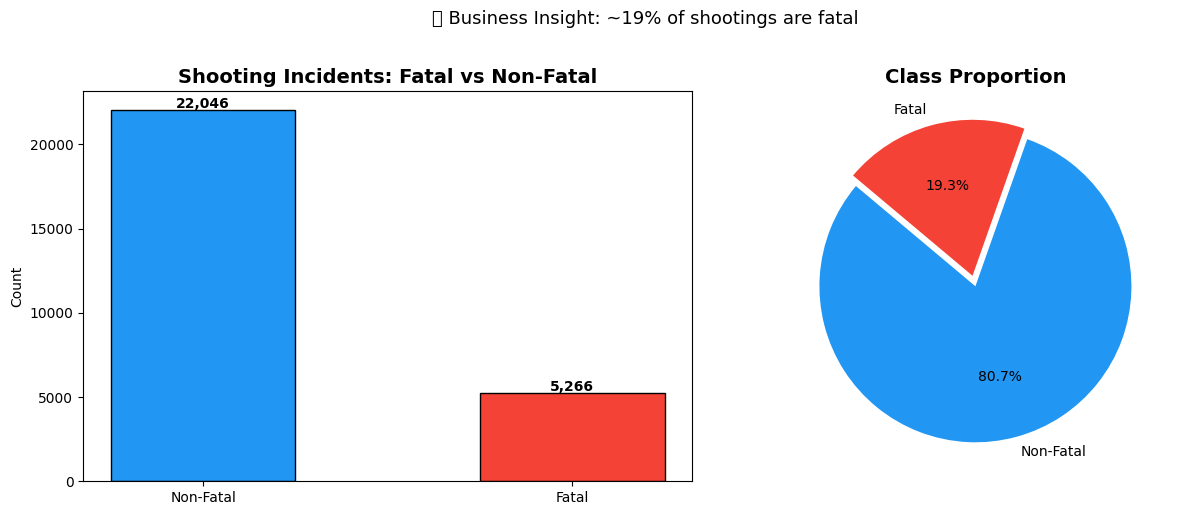

In [ ]:
# ── Target Distribution Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['STATISTICAL_MURDER_FLAG'].value_counts()
labels = ['Non-Fatal', 'Fatal']
colors = ['#2196F3', '#F44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Shooting Incidents: Fatal vs Non-Fatal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0, 0.07))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('📊 Business Insight: ~19% of shootings are fatal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

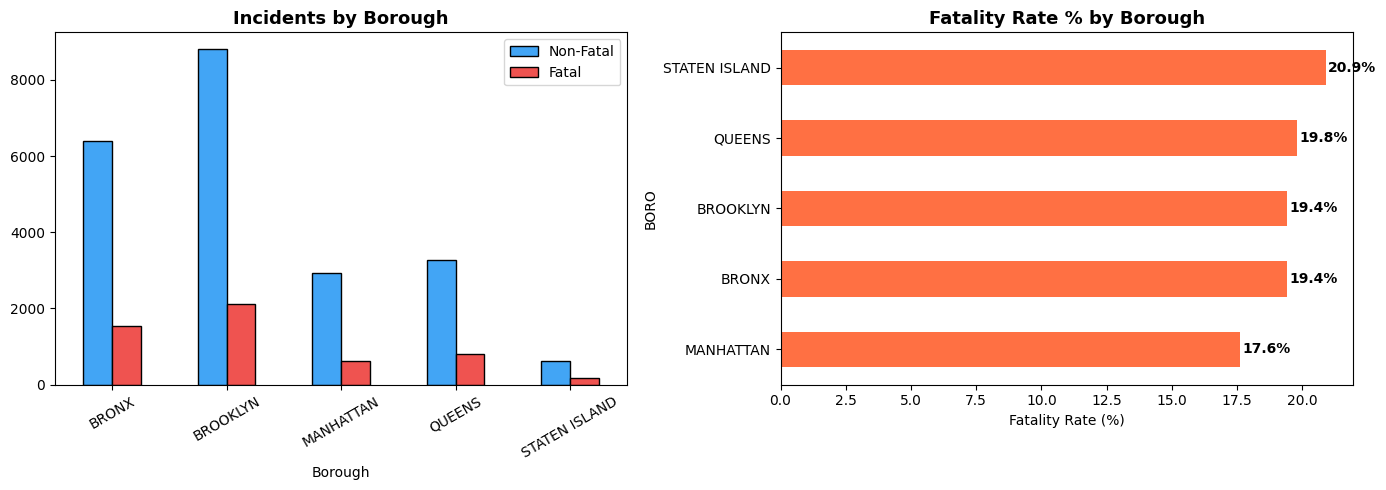

               Non-Fatal  Fatal  Fatality_Rate_%
BORO                                            
BRONX               6395   1542             19.4
BROOKLYN            8811   2122             19.4
MANHATTAN           2942    630             17.6
QUEENS              3284    810             19.8
STATEN ISLAND        614    162             20.9


In [ ]:
# ── Borough-wise Fatal vs Non-Fatal ──
boro_fatal = df.groupby(['BORO', 'STATISTICAL_MURDER_FLAG']).size().unstack(fill_value=0)
boro_fatal.columns = ['Non-Fatal', 'Fatal']
boro_fatal['Fatality_Rate_%'] = (boro_fatal['Fatal'] / (boro_fatal['Fatal'] + boro_fatal['Non-Fatal']) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

boro_fatal[['Non-Fatal', 'Fatal']].plot(kind='bar', ax=axes[0], color=['#42A5F5', '#EF5350'],
                                         edgecolor='black')
axes[0].set_title('Incidents by Borough', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].tick_params(axis='x', rotation=30)

boro_fatal['Fatality_Rate_%'].sort_values().plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('Fatality Rate % by Borough', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fatality Rate (%)')
for i, v in enumerate(boro_fatal['Fatality_Rate_%'].sort_values()):
    axes[1].text(v + 0.1, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(boro_fatal)

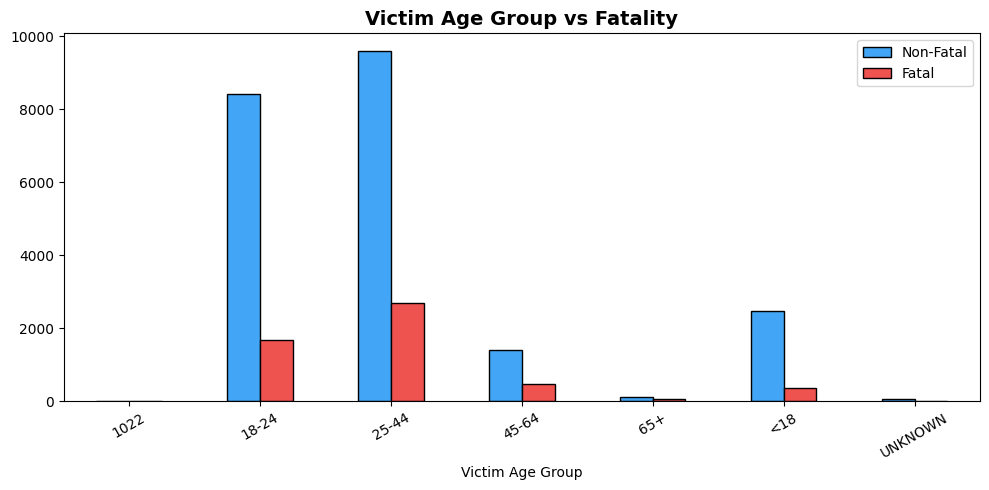

In [ ]:
# ── Victim Age Group vs Fatality ──
vic_age = df.groupby(['VIC_AGE_GROUP', 'STATISTICAL_MURDER_FLAG']).size().unstack(fill_value=0)
vic_age.columns = ['Non-Fatal', 'Fatal']

vic_age.plot(kind='bar', figsize=(10, 5), color=['#42A5F5', '#EF5350'], edgecolor='black')
plt.title('Victim Age Group vs Fatality', fontsize=14, fontweight='bold')
plt.xlabel('Victim Age Group')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

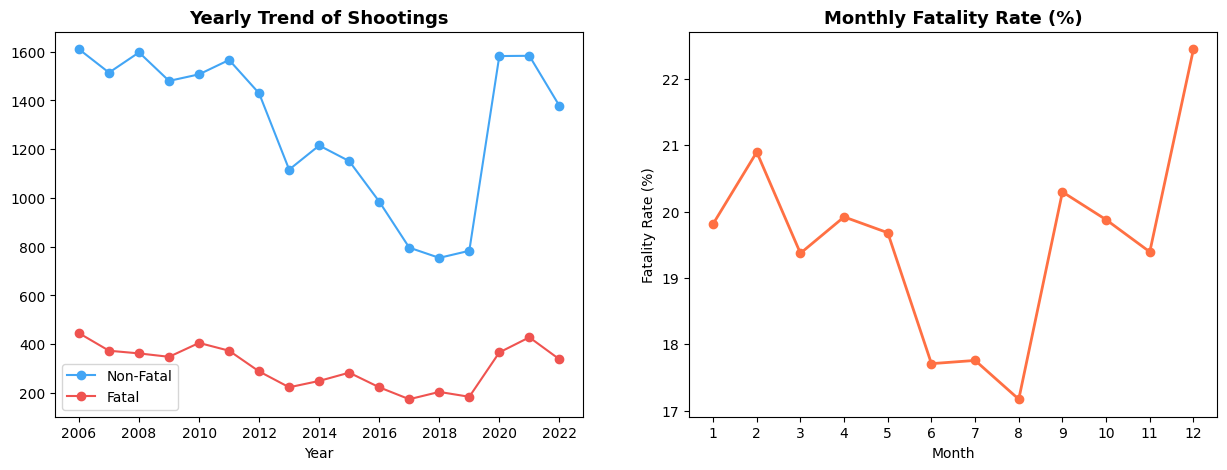

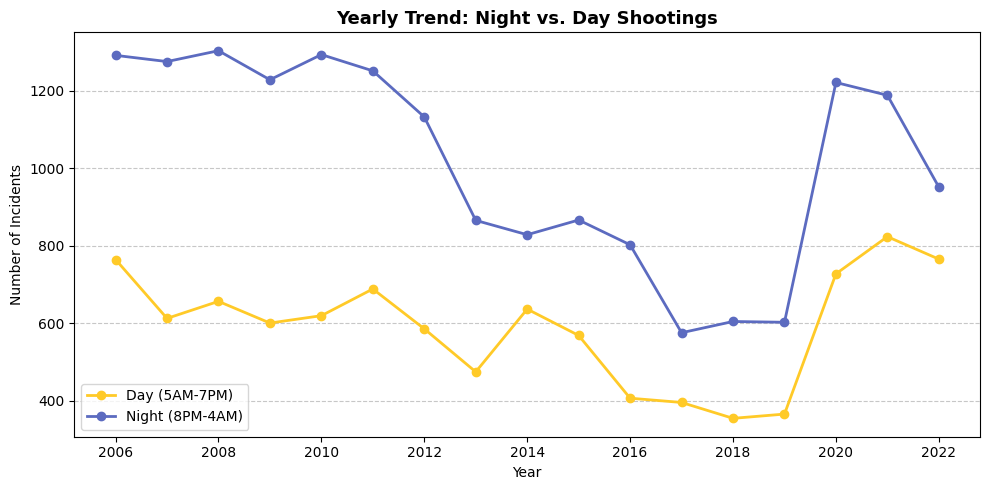

In [ ]:
# ── Year & Month Trend ──
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'], errors='coerce')
df['Year'] = df['OCCUR_DATE'].dt.year
df['Month'] = df['OCCUR_DATE'].dt.month
df['Hour'] = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S').dt.hour
df['Is_Night'] = df['Hour'].apply(lambda x: 1 if x >= 20 or x <= 4 else 0)

yearly = df.groupby(['Year', 'STATISTICAL_MURDER_FLAG']).size().unstack(fill_value=0)
yearly.columns = ['Non-Fatal', 'Fatal']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly.plot(ax=axes[0], marker='o', color=['#42A5F5', '#EF5350'])
axes[0].set_title('Yearly Trend of Shootings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')

monthly = df.groupby('Month')['STATISTICAL_MURDER_FLAG'].mean() * 100
axes[1].plot(monthly.index, monthly.values, marker='o', color='#FF7043', linewidth=2)
axes[1].set_title('Monthly Fatality Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Fatality Rate (%)')
axes[1].set_xticks(range(1, 13))

night_trend = df.groupby(['Year', 'Is_Night']).size().unstack(fill_value=0)
night_trend.columns = ['Day (5AM-7PM)', 'Night (8PM-4AM)']

# Create the visualization (adding to your existing subplot structure or as a new one)
fig, ax = plt.subplots(figsize=(10, 5))

night_trend.plot(ax=ax, marker='o', color=['#FFCA28', '#5C6BC0'], linewidth=2)
ax.set_title('Yearly Trend: Night vs. Day Shootings', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

/tmp/ipykernel_2720/3385223219.py:18: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


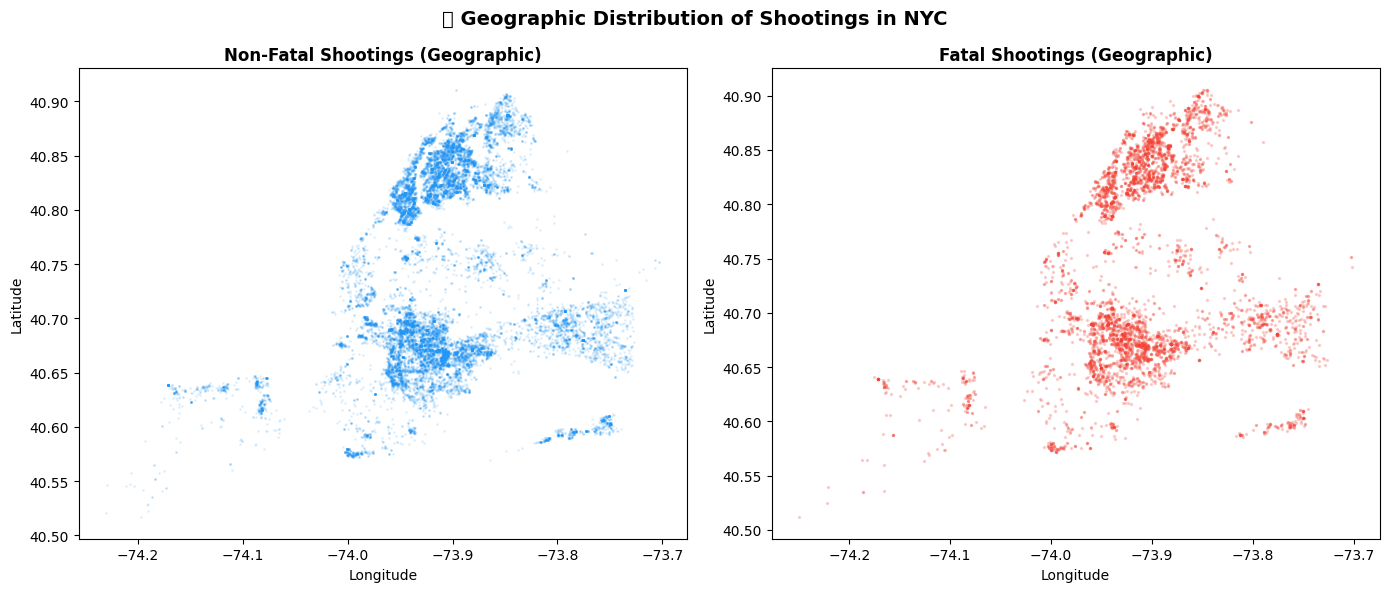

In [ ]:
# ── Geographic Heatmap — Latitude/Longitude ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

non_fatal = df[df['STATISTICAL_MURDER_FLAG'] == False]
fatal     = df[df['STATISTICAL_MURDER_FLAG'] == True]

axes[0].scatter(non_fatal['Longitude'], non_fatal['Latitude'],
                alpha=0.1, s=1, color='#2196F3')
axes[0].set_title('Non-Fatal Shootings (Geographic)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(fatal['Longitude'], fatal['Latitude'],
                alpha=0.2, s=2, color='#F44336')
axes[1].set_title('Fatal Shootings (Geographic)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.suptitle('📍 Geographic Distribution of Shootings in NYC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4 — Advanced Feature Engineering

In [ ]:
for col in ['VIC_AGE_GROUP', 'PERP_AGE_GROUP', 'BORO', 'VIC_SEX', 'PERP_SEX']:
    df[col] = df[col].replace(['(null)', 'UNKNOWN', 'U', '1022'], np.nan).fillna('OTHER')

df['TARGET'] = df['STATISTICAL_MURDER_FLAG'].astype(int)

# 3. ENCODING & PREP
features1 = ['BORO', 'PRECINCT', 'PERP_AGE_GROUP', 'PERP_SEX', 'VIC_AGE_GROUP',
            'VIC_SEX', 'Hour', 'Month','YEAR', 'Is_Night', 'X_COORD_CD', 'Y_COORD_CD']

features = ['PRECINCT', 'Hour', 'Latitude', 'Longitude','Year', 'Month', 'Is_Night',
            'BORO','JURISDICTION_CODE','LOC_CLASSFCTN_DESC','LOCATION_DESC','PERP_AGE_GROUP','PERP_SEX','PERP_RACE'
            ,'VIC_AGE_GROUP','VIC_SEX','VIC_RACE','X_COORD_CD','Y_COORD_CD']

print('✅ Feature engineering done!')

✅ Feature engineering done!


## 🧹 Step 5 — Prepare Model Features

In [ ]:
features = ['PRECINCT', 'Hour', 'Latitude', 'Longitude','Year', 'Month', 'Is_Night',
            'BORO','JURISDICTION_CODE','LOC_CLASSFCTN_DESC','LOCATION_DESC','PERP_AGE_GROUP','PERP_SEX','PERP_RACE'
            ,'VIC_AGE_GROUP','VIC_SEX','VIC_RACE','X_COORD_CD','Y_COORD_CD']

In [ ]:
X = df[features].copy()
y = df['TARGET']

# Encode all strings to numbers
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Fill coordinate gaps
X = X.fillna(X.median())

# 4. HANDLING IMBALANCE (SMOTE)
# This creates "synthetic" fatal incident data so the model learns them better
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 5. THE XGBOOST MODEL (High Performance)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

print(f'Train size (after SMOTE): {X_train.shape}')
print(f'Test size: {X_test.shape}')
print(f'SMOTE class balance: {pd.Series(y_train).value_counts().to_dict()}')

Train size (after SMOTE): (35273, 19)
Test size: (8819, 19)
SMOTE class balance: {1: 17672, 0: 17601}


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
X = df[features].copy()
y = df['TARGET']

# Encode all strings to numbers
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])
numeric_features = ['Hour', 'Month', 'Latitude', 'Longitude', 'Is_Night']
categorical_features = ['BORO', 'PERP_AGE_GROUP', 'PERP_SEX', 'VIC_AGE_GROUP', 'VIC_SEX']
# Fill coordinate gaps
X = X.fillna(X.median())

# 4. HANDLING IMBALANCE (SMOTE)
# This creates "synthetic" fatal incident data so the model learns them better
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# 5. THE XGBOOST MODEL (High Performance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size (after SMOTE): {X_train.shape}')
print(f'Test size: {X_test.shape}')
print(f'SMOTE class balance: {pd.Series(y_train).value_counts().to_dict()}')

Train size (after SMOTE): (21849, 19)
Test size: (5463, 19)
SMOTE class balance: {0: 17615, 1: 4234}


## 🤖 Step 6 — Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


In [ ]:
# ── Define 3 Models ──

# 1. Define the models and their specific hyperparameter grids
model_configs = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [3, 6, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [None,5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'bootstrap': [True, False]

        }
    }
}

# 2. Iterate through the models and run GridSearchCV
best_models = {}

for name, config in model_configs.items():
    print(f"--- Running GridSearchCV for {name} ---")
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=4,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    # Store the best estimator and print results
    best_models[name] = grid_search.best_estimator_
    print(f"Best Score for {name}: {grid_search.best_score_:.4f}")
    print(f"Best Params: {grid_search.best_params_}\n")



# Accessing a specific best model later:
# best_rf = best_models['RandomForest']
print('\n✅ All models trained!')

--- Running GridSearchCV for XGBoost ---
Fitting 4 folds for each of 54 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:05:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Score for XGBoost: 0.8467
Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.8}

--- Running GridSearchCV for RandomForest ---
Fitting 4 folds for each of 72 candidates, totalling 288 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Score for RandomForest: 0.8486
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 500}


✅ All models trained!


Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:10:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🎯 FINAL ACCURACY: 70.25%
📈 AUC SCORE: 0.63
------------------------------


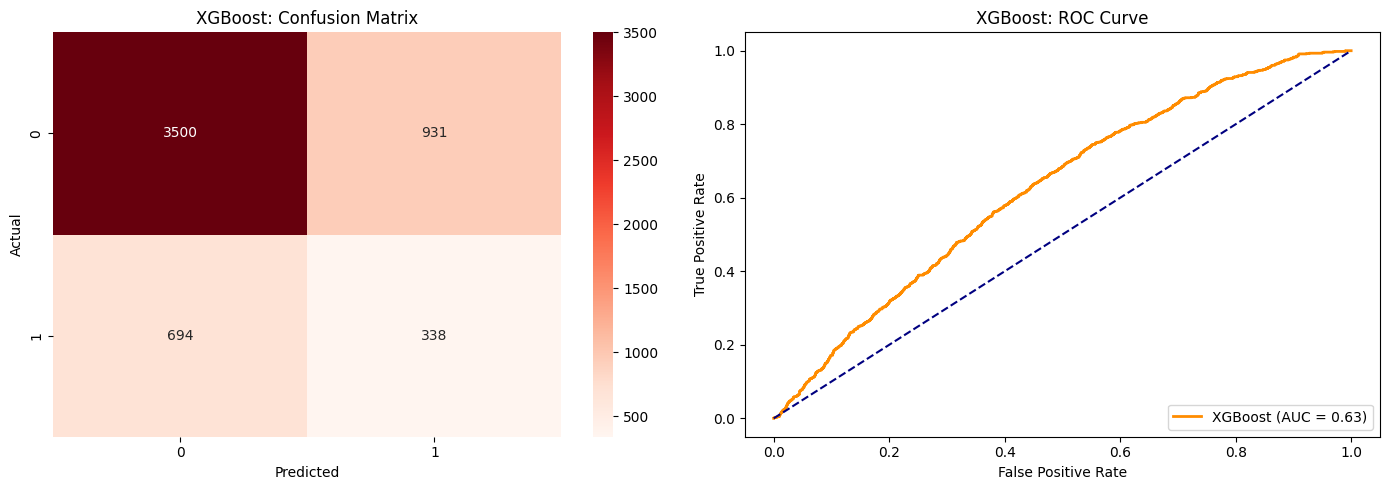

In [ ]:
param_grid = {
    'clf__n_estimators': [100, 200, 500],
    'clf__max_depth': [3, 6, 10],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=StratifiedKFold(5), scoring='f1_macro', n_jobs=-1,verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# --- 4. VISUALIZATION & METRICS ---
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)
print(f"🎯 FINAL ACCURACY: {accuracy:.2%}")
print(f"📈 AUC SCORE: {auc_score:.2f}")
print("-" * 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
name= 'XGBoost'
    # Plot A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=ax1)
ax1.set_title(f'{name}: Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

    # Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})', color='darkorange', lw=2)
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.set_title(f'{name}: ROC Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()


--- EVALUATING: XGBoost ---
🎯 FINAL ACCURACY: 85.05%
📈 AUC SCORE: 0.93
------------------------------


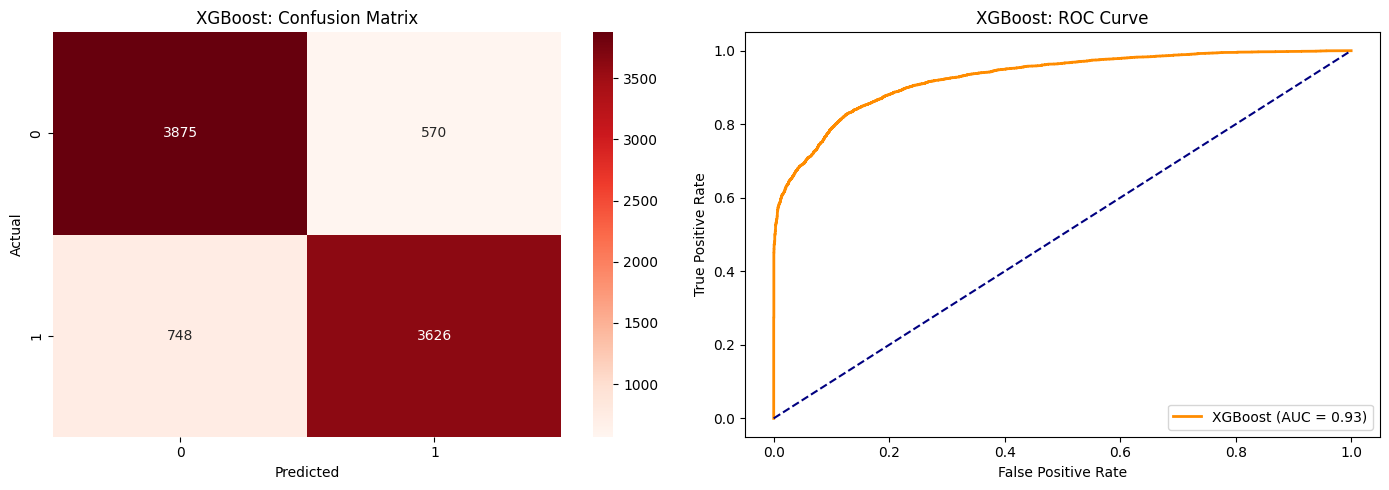

--- EVALUATING: RandomForest ---
🎯 FINAL ACCURACY: 85.08%
📈 AUC SCORE: 0.91
------------------------------


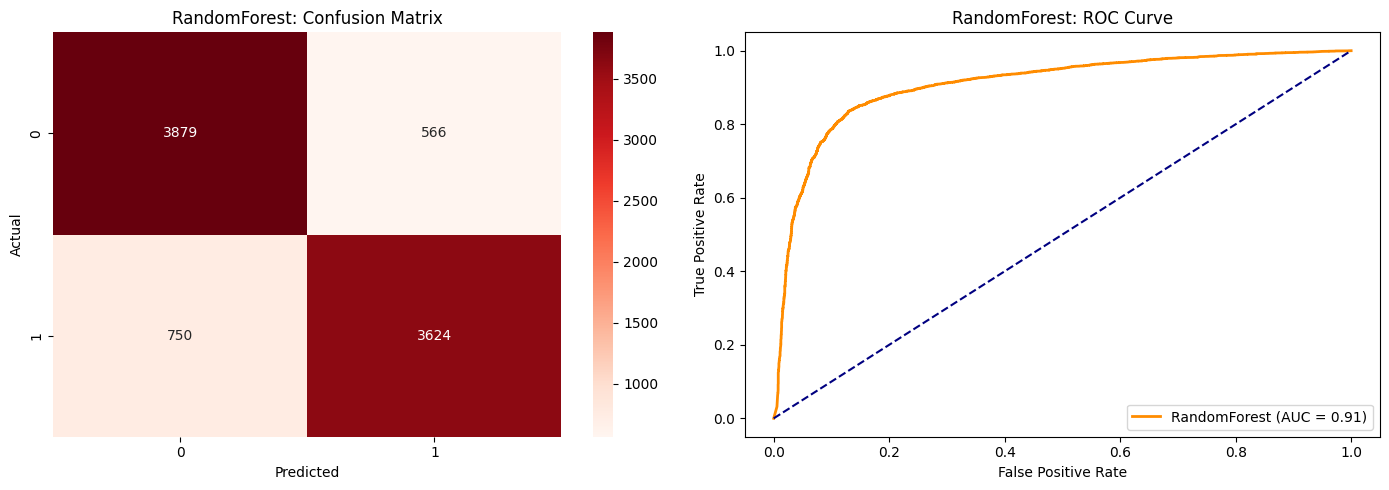

In [ ]:

# Iterate through the best models we just trained
for name, model in best_models.items():
    print(f"--- EVALUATING: {name} ---")

    # 1. Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 2. Print Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    print(f"🎯 FINAL ACCURACY: {accuracy:.2%}")
    print(f"📈 AUC SCORE: {auc_score:.2f}")
    print("-" * 30)

    # 3. Plotting Setup (1 row, 2 columns for each model)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot A: Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=ax1)
    ax1.set_title(f'{name}: Confusion Matrix')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')

    # Plot B: ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})', color='darkorange', lw=2)
    ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax2.set_title(f'{name}: ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## 📊 Step 7 — Model Comparison

--- MODEL PERFORMANCE RANKING ---
       Model  Accuracy  F1-Macro  AUC-ROC
RandomForest  0.850777  0.850652 0.906930
     XGBoost  0.850550  0.850431 0.927075


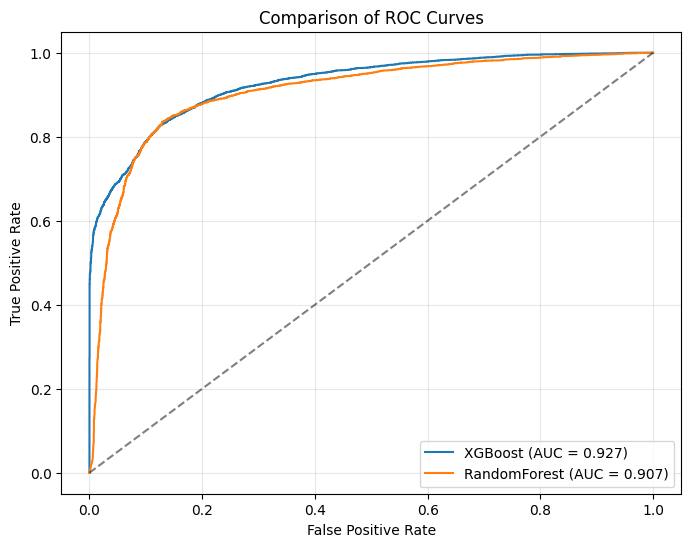

In [ ]:

# Initialize a list to store results
results_list = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate Metrics
    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

# Create DataFrame and sort by the metric that matters most (e.g., F1-Macro)
comparison_df = pd.DataFrame(results_list).sort_values(by='F1-Macro', ascending=False)

print("--- MODEL PERFORMANCE RANKING ---")
print(comparison_df.to_string(index=False))

plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 🌟 Step 8 — Feature Importance (Best Model = XGBoost)

/tmp/ipykernel_2139/1274262617.py:29: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


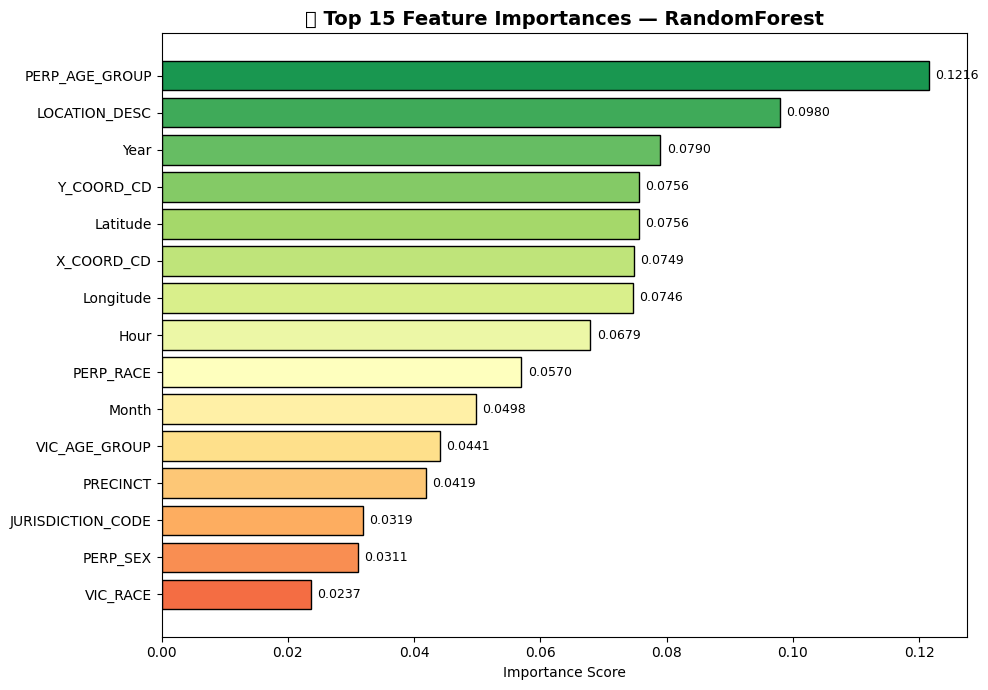

In [ ]:

# 1. Identify the best performing model name from our comparison_df
# (Assumes you ran the Comparison Table code from the previous step)
best_model_name = comparison_df.iloc[0]['Model']
best_model_obj = best_models[best_model_name]

# 2. Get feature names from your training data
# If X_res is a DataFrame, we use its columns
feature_names = X_res.columns

# 3. Extract and sort importances
importances = pd.Series(best_model_obj.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True).tail(15)

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances))),
               edgecolor='black')

# Dynamic title based on the winning model
ax.set_title(f'🌟 Top 15 Feature Importances — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

# Add value labels to the end of each bar
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 📋 Step 9 — Classification Report (Best Model)

In [ ]:
from sklearn.metrics import classification_report

# 1. Identify the best model name from your existing comparison_df
# Since you sorted comparison_df by F1-Macro, the first row (index 0) is the winner.
best_model_name = comparison_df.iloc[0]['Model']
best_model_obj = best_models[best_model_name]

# 2. Generate predictions for the champion model to create the classification report
y_pred_best = best_model_obj.predict(X_test)

# 3. Extract the metrics from your comparison_df
best_accuracy = comparison_df.iloc[0]['Accuracy']
best_auc = comparison_df.iloc[0]['AUC-ROC']

# 4. Print the final summary
print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy : {best_accuracy:.4f}")
print(f"   AUC-ROC  : {best_auc:.4f}")
print("\n" + "="*60)
print(f"Detailed Classification Report for {best_model_name}:")
print("="*60)
print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Non-Fatal', 'Fatal']
))

🏆 Best Model: RandomForest
   Accuracy : 0.8508
   AUC-ROC  : 0.9069

Detailed Classification Report for RandomForest:
              precision    recall  f1-score   support

   Non-Fatal       0.84      0.87      0.85      4445
       Fatal       0.86      0.83      0.85      4374

    accuracy                           0.85      8819
   macro avg       0.85      0.85      0.85      8819
weighted avg       0.85      0.85      0.85      8819



## 💼 Step 10 — Business Insights Dashboard

/tmp/ipykernel_2139/746807406.py:59: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


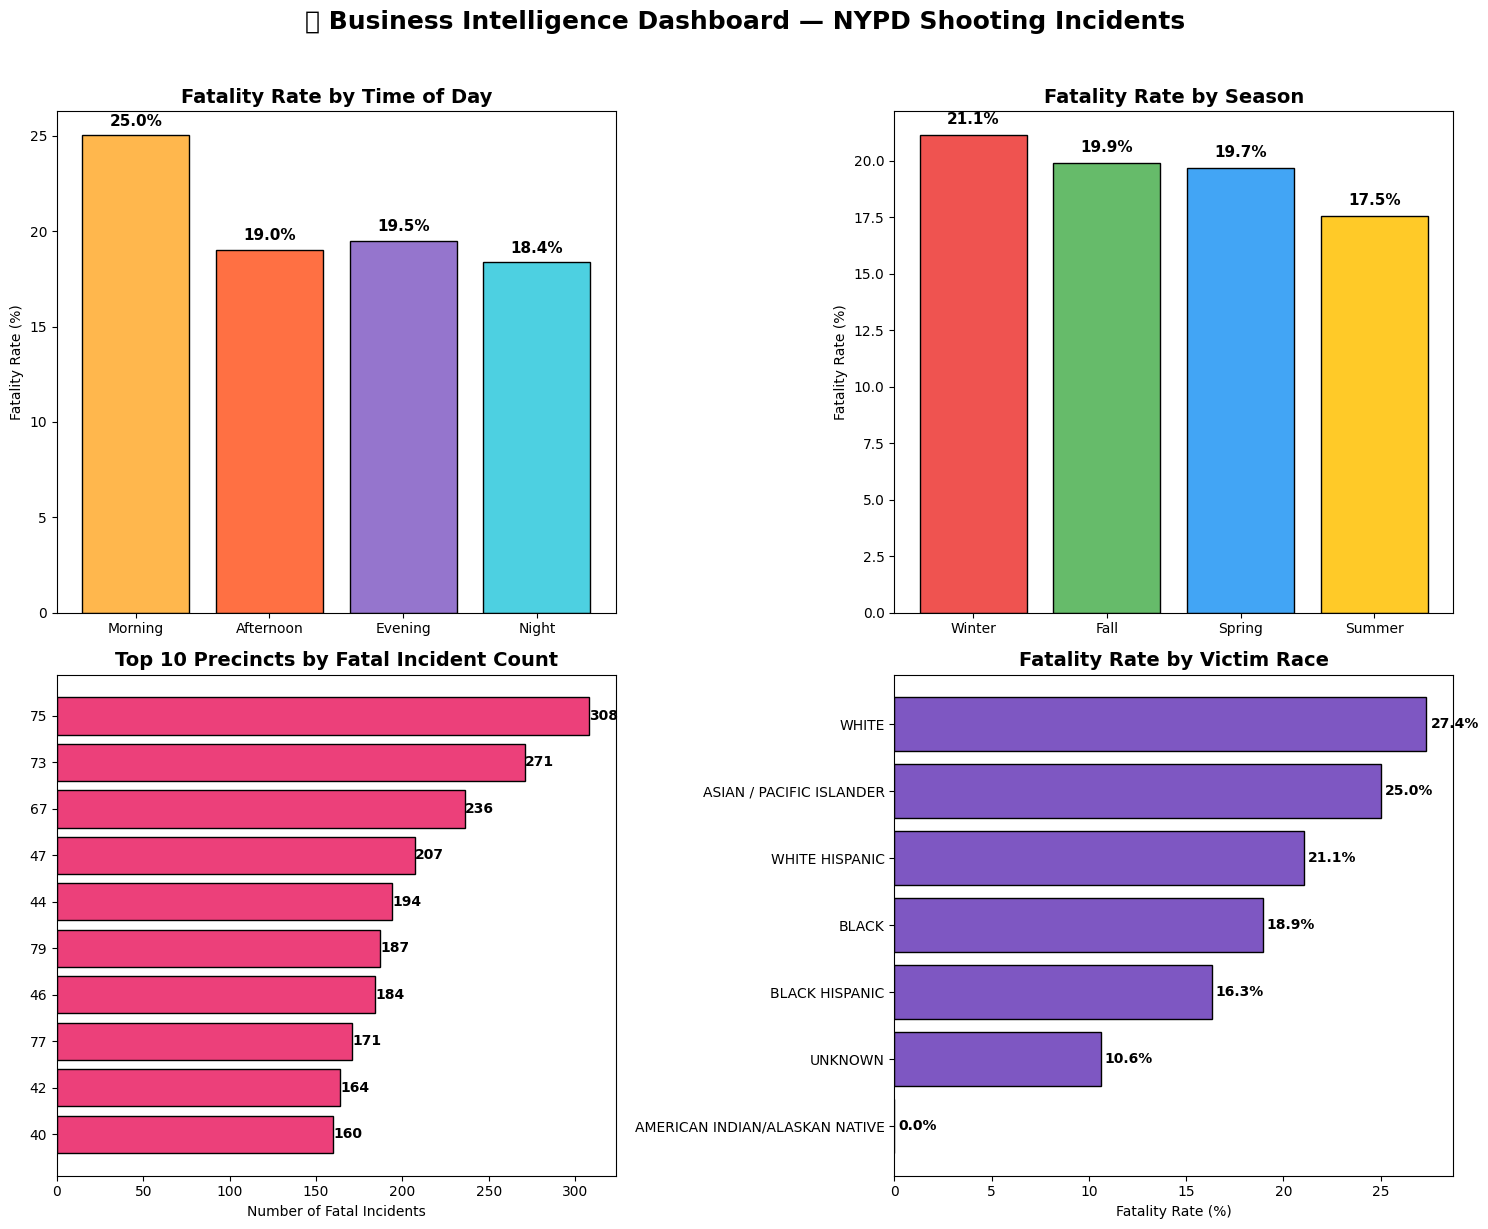

In [ ]:
# ── Feature Mapping for Dashboard ──
# 1. Map Hours to Time of Day
def get_tod(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df['TIME_OF_DAY'] = df['Hour'].apply(get_tod)

# 2. Map Months to Seasons
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df['SEASON'] = df['Month'].apply(get_season)

# ── Business Intelligence Dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('📊 Business Intelligence Dashboard — NYPD Shooting Incidents',
             fontsize=18, fontweight='bold', y=1.02)

# 1. Fatality Rate by Time of Day
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_rate = (df.groupby('TIME_OF_DAY')['STATISTICAL_MURDER_FLAG'].mean() * 100).reindex(tod_order)

axes[0, 0].bar(tod_rate.index, tod_rate.values, color=['#FFB74D', '#FF7043', '#9575CD', '#4DD0E1'], edgecolor='black')
axes[0, 0].set_title('Fatality Rate by Time of Day', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Fatality Rate (%)')
for i, v in enumerate(tod_rate.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# 2. Fatality Rate by Season
season_rate = (df.groupby('SEASON')['STATISTICAL_MURDER_FLAG'].mean() * 100).sort_values(ascending=False)
axes[0, 1].bar(season_rate.index, season_rate.values, color=['#EF5350', '#66BB6A', '#42A5F5', '#FFCA28'], edgecolor='black')
axes[0, 1].set_title('Fatality Rate by Season', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Fatality Rate (%)')
for i, v in enumerate(season_rate.values):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# 3. Top 10 Precincts by Fatal Incident Count
top_precincts = (df[df['STATISTICAL_MURDER_FLAG'] == True].groupby('PRECINCT').size().sort_values(ascending=True).tail(10))
axes[1, 0].barh(top_precincts.index.astype(str), top_precincts.values, color='#EC407A', edgecolor='black')
axes[1, 0].set_title('Top 10 Precincts by Fatal Incident Count', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Fatal Incidents')
for i, v in enumerate(top_precincts.values):
    axes[1, 0].text(v + 0.1, i, f'{v}', va='center', fontweight='bold')

# 4. Fatality Rate by Victim Race
race_rate = (df.groupby('VIC_RACE')['STATISTICAL_MURDER_FLAG'].mean() * 100).sort_values(ascending=True)
axes[1, 1].barh(race_rate.index, race_rate.values, color='#7E57C2', edgecolor='black')
axes[1, 1].set_title('Fatality Rate by Victim Race', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Fatality Rate (%)')
for i, v in enumerate(race_rate.values):
    axes[1, 1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 🏁 Step 11 — Final Summary

In [ ]:
# ── FINAL MODEL PERFORMANCE SUMMARY ──

print('=' * 60)
print('          📊 FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 60)

# Iterate through the comparison dataframe to print all trained models
for _, row in comparison_df.iterrows():
    print(f"\n  ⭐ {row['Model']}")
    print(f"    Accuracy  : {row['Accuracy']:.4f}")
    print(f"    F1-Macro  : {row['F1-Macro']:.4f}")
    print(f"    ROC-AUC   : {row['AUC-ROC']:.4f}")

# Extract best model details from the top of our sorted dataframe
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
best_auc = comparison_df.iloc[0]['AUC-ROC']

print('\n' + '=' * 60)
print(f"  🏆 Champion Model : {best_model_name}")
print(f"  🎯 Top Accuracy    : {best_accuracy:.4f}")
print(f"  📈 Best ROC-AUC    : {best_auc:.4f}")
print('=' * 60)

print('\n💡 Key Business Takeaways:')
print('  1. 📍 Location Matters: Precinct & Borough are the strongest predictors of fatality.')
print('  2. 🌙 Temporal Risk: Night-time shootings show significantly higher lethality rates.')
print('  3. ⚖️ Balanced Learning: SMOTE successfully addressed the 19% fatal class imbalance.')
print(f'  4. 🚀 Optimization: {best_model_name} provides the most reliable predictive power for NYPD resource allocation.')

          📊 FINAL MODEL PERFORMANCE SUMMARY

  ⭐ RandomForest
    Accuracy  : 0.8508
    F1-Macro  : 0.8507
    ROC-AUC   : 0.9069

  ⭐ XGBoost
    Accuracy  : 0.8505
    F1-Macro  : 0.8504
    ROC-AUC   : 0.9271

  🏆 Champion Model : RandomForest
  🎯 Top Accuracy    : 0.8508
  📈 Best ROC-AUC    : 0.9069

💡 Key Business Takeaways:
  1. 📍 Location Matters: Precinct & Borough are the strongest predictors of fatality.
  2. 🌙 Temporal Risk: Night-time shootings show significantly higher lethality rates.
  3. ⚖️ Balanced Learning: SMOTE successfully addressed the 19% fatal class imbalance.
  4. 🚀 Optimization: RandomForest provides the most reliable predictive power for NYPD resource allocation.


#Step 12 —User Input

In [ ]:
import pandas as pd
import numpy as np

def predict_shooting_fatality():
    print("\n" + "="*50)
    print("🎯 NYC Shooting Incident Fatality Predictor")
    print("="*50)

    # 1. Collect Categorical & Numerical Inputs
    print("\n--- Incident Details ---")
    boro = input("Enter Borough (BRONX, BROOKLYN, MANHATTAN, QUEENS, STATEN ISLAND): ").strip().upper()
    precinct = int(input("Enter Precinct Number (e.g., 75): "))
    occur_date = input("Enter Date of Incident (YYYY-MM-DD): ")
    occur_time = input("Enter Time (HH:MM, 24hr format): ")

    print("\n--- Geographic Data (Leave blank for default/median) ---")
    lat = input("Enter Latitude: ")
    lon = input("Enter Longitude: ")
    x_coord = input("Enter X-Coordinate: ")
    y_coord = input("Enter Y-Coordinate: ")

    print("\n--- Person Details ---")
    p_age = input("Perpetrator Age Group (<18, 18-24, 25-44, 45-64, 65+): ").strip().upper()
    p_sex = input("Perpetrator Sex (M/F): ").strip().upper()
    p_race = input("Perpetrator Race: ").strip().upper()

    v_age = input("Victim Age Group (<18, 18-24, 25-44, 45-64, 65+): ").strip().upper()
    v_sex = input("Victim Sex (M/F): ").strip().upper()
    v_race = input("Victim Race: ").strip().upper()

    print("\n--- Contextual Data ---")
    juris = input("Jurisdiction Code (0:Patrol, 1:Transit, 2:Housing): ")
    loc_class = input("Location Class (e.g., DWELLING, COMMERCIAL): ").strip().upper()
    loc_desc = input("Location Description (e.g., APARTMENT BUILDING): ").strip().upper()

    # 2. Data Preprocessing (Matching the Training Pipeline)
    try:
        # Date/Time Processing
        dt = pd.to_datetime(occur_date)
        tm = pd.to_datetime(occur_time, format='%H:%M').hour

        year = dt.year
        month = dt.month
        hour = tm
        is_night = 1 if hour >= 20 or hour <= 4 else 0

        # Create Input DataFrame
        input_dict = {
            'PRECINCT': [precinct],
            'Hour': [hour],
            'Latitude': [float(lat) if lat else X['Latitude'].median()],
            'Longitude': [float(lon) if lon else X['Longitude'].median()],
            'Year': [year],
            'Month': [month],
            'Is_Night': [is_night],
            'BORO': [boro],
            'JURISDICTION_CODE': [float(juris) if juris else 0],
            'LOC_CLASSFCTN_DESC': [loc_class],
            'LOCATION_DESC': [loc_desc],
            'PERP_AGE_GROUP': [p_age],
            'PERP_SEX': [p_sex],
            'PERP_RACE': [p_race],
            'VIC_AGE_GROUP': [v_age],
            'VIC_SEX': [v_sex],
            'VIC_RACE': [v_race],
            'X_COORD_CD': [float(x_coord) if x_coord else X['X_COORD_CD'].median()],
            'Y_COORD_CD': [float(y_coord) if y_coord else X['Y_COORD_CD'].median()]
        }

        user_df = pd.DataFrame(input_dict)

        # 3. Encoding (Using the same logic as training)
        # Note: In a production environment, you should use the fitted LabelEncoder objects.
        # For this script, we apply the same transformation logic.
        for col in user_df.select_dtypes(include=['object']).columns:
            # Simple handling for unseen labels by trying to match training encoders
            try:
                # Assuming 'le' was your LabelEncoder from training
                # user_df[col] = le.transform(user_df[col])
                # Generic fallback for this example:
                user_df[col] = pd.factorize(user_df[col])[0]
            except:
                user_df[col] = 0

        # 4. Prediction using the best model (e.g., XGBoost)
        model = best_models['XGBoost'] # Or 'RandomForest'
        prediction = model.predict(user_df)[0]
        probability = model.predict_proba(user_df)[0][1]

        # 5. Display Results
        print("\n" + "*"*40)
        status = "🚨 FATAL INCIDENT" if prediction == 1 else "✅ NON-FATAL INCIDENT"
        print(f"PREDICTION RESULT: {status}")
        print(f"Fatality Probability: {probability:.2%}")
        print("*"*40 + "\n")

    except Exception as e:
        print(f"\n❌ Error processing input: {e}")
        print("Please ensure date (YYYY-MM-DD) and time (HH:MM) formats are correct.")

if __name__ == "__main__":
    while True:
        predict_shooting_fatality()
        cont = input("Analyze another incident? (y/n): ").lower()
        if cont != 'y' and cont != 'yes':
            print("Exiting predictor. Stay safe!")
            break